In [1]:
from __future__ import annotations

from dataclasses import dataclass

import petsc4py.PETSc as PETSc
import numpy as np
from ufl import det, tr

from homicsx import(
    Inclusion,
    RVEGeometry, 
    PhysicalTags, 
    MeshSettings,
    MaterialAssignment,
    ProblemSettings,
)
from homicsx.core.material import HyperelasticMaterial, MaterialState
from homicsx.mesh import generate_mesh
from homicsx.core.homogenization import AdaptiveSettings
from homicsx.homogenization.driver import NonlinearHomogenizationDriver

Custom geometry and mesh generation

In [2]:
dim = 2
domain_size = (1, 1)

inclusion = Inclusion(
    center=[0.5, 0.5],
    phase_id=1,
    shape='circle',
    radii=0.2,
)

geometry = RVEGeometry(
    dim=dim,
    domain_size=domain_size,
    inclusions=[inclusion],
)

physical_tags = PhysicalTags()

mesh_settings = MeshSettings(
    min_size=0.02,
    max_size=0.04,
    physical_tags=physical_tags,
    quad_hex=True,
)

domain, ct, ft = generate_mesh(
    geometry=geometry,
    mesh_settings=mesh_settings,
)

Custom hyperelastic material definition

In [3]:
@dataclass
class NeoHookeanDecoupled(HyperelasticMaterial):
    def __init__(self, kappa, mu):
        self.kappa = kappa
        self.mu = mu
    
    def psi_form(self, F):
        dim = F.ufl_shape[0]
        C = F.T * F
        J = det(F)
        I1 = J**(-2/3) * (tr(C) + 1)
        return self.kappa/2 * (J - 1)**2 + self.mu/2 * (I1 - 3)
    
    def evaluate_energy(self, F: np.ndarray, dim: int) -> float:
        """Numeric evaluation matching psi_form."""
        J = np.linalg.det(F)
        C = F.T @ F
        tr_C = np.trace(C)
        if dim == 2:
            I1 = J**(-2/3) * (tr_C + 1)
        else:
            I1 = J**(-2/3) * tr_C
        return self.kappa/2 * (J - 1)**2 + self.mu/2 * (I1 - 3)
    
    def get_quadrature_point_stress(self, state: MaterialState, F: np.ndarray, quad_point_idx: int) -> np.ndarray:
        dim = F.shape[0]
        J = np.linalg.det(F)
        Finv = np.linalg.inv(F)
        FinvT = Finv.T
        
        C = F.T @ F
        tr_C = np.trace(C)
        
        P_iso = self.mu * J**(-2.0/3.0) * (F - (1.0/3.0) * tr_C * FinvT)
        P_vol = self.kappa * J * (J - 1.0) * FinvT
        
        return P_iso + P_vol

kappa_mat = 17.5
mu_mat = 8.0
mat_matrix = NeoHookeanDecoupled(kappa=kappa_mat, mu=mu_mat)

kappa_inc = 100 * kappa_mat
mu_inc = 100 * mu_mat
mat_inclusion = NeoHookeanDecoupled(kappa=kappa_inc, mu=mu_inc)

material_assignment = MaterialAssignment(
    materials_by_phase={
        0: mat_matrix,
        1: mat_inclusion,
    }
)

Solution with custom loading


STARTING HOMOGENIZATION ANALYSIS
   Dimension: 2D
   Number of load cases: 1
   Max strain: 0.4
   History-dependent materials: False


######################################################################
Load Case 1/1: tension
######################################################################

STARTING LOAD CASE: tension
   Target Load: 0.4000 | Initial da: 3.20e-02

Step   1 | Progress:   8.00% | Load: 0.032000 | da: 3.20e-02
   Strain increment da: 3.20e-02 | Physical dt: 0.00e+00
   Attempting da: 3.20e-02
   SUCCESS: Converged in 3 iterations.
   Stats: Wbar=1.7260e-02 | Jbar=1.0320 | P_max=1.0724e+00
   Computing Tangent stiffness...
   Done.
   Increasing step size: 3.20e-02 -> 4.16e-02

Step   2 | Progress:  18.40% | Load: 0.073600 | da: 4.16e-02
   Strain increment da: 4.16e-02 | Physical dt: 0.00e+00
   Attempting da: 4.16e-02
   SUCCESS: Converged in 4 iterations.
   Stats: Wbar=8.9971e-02 | Jbar=1.0736 | P_max=2.4142e+00
   Computing Tangent stiffness...
   Done.
   

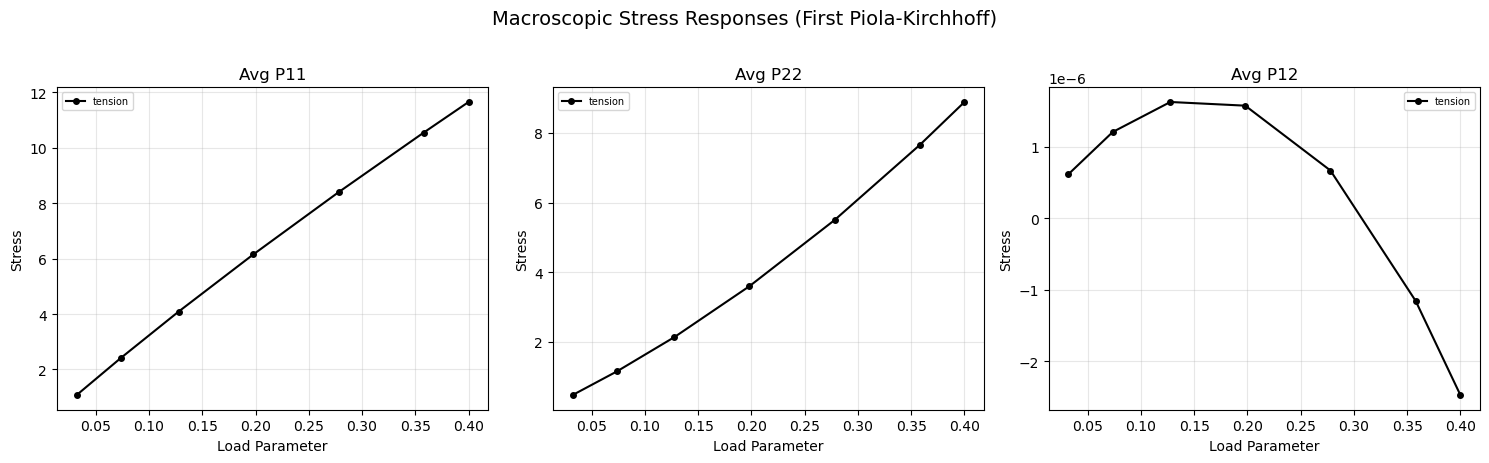

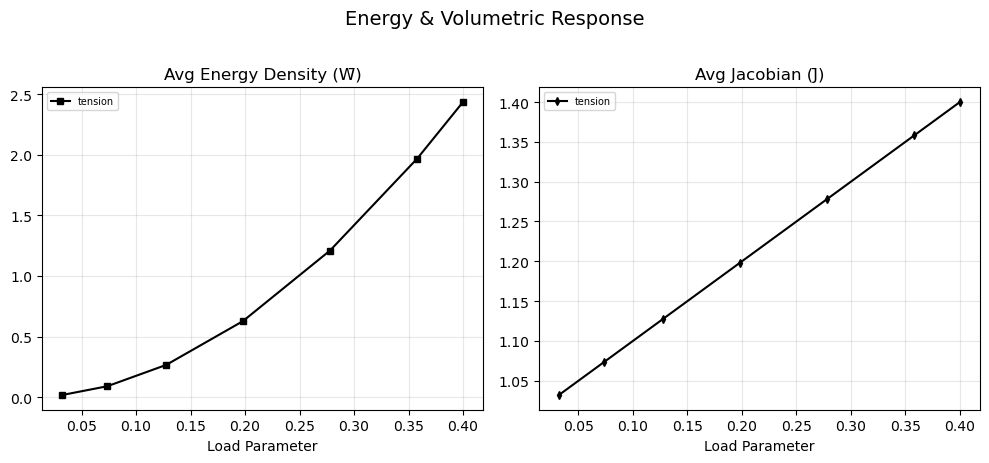

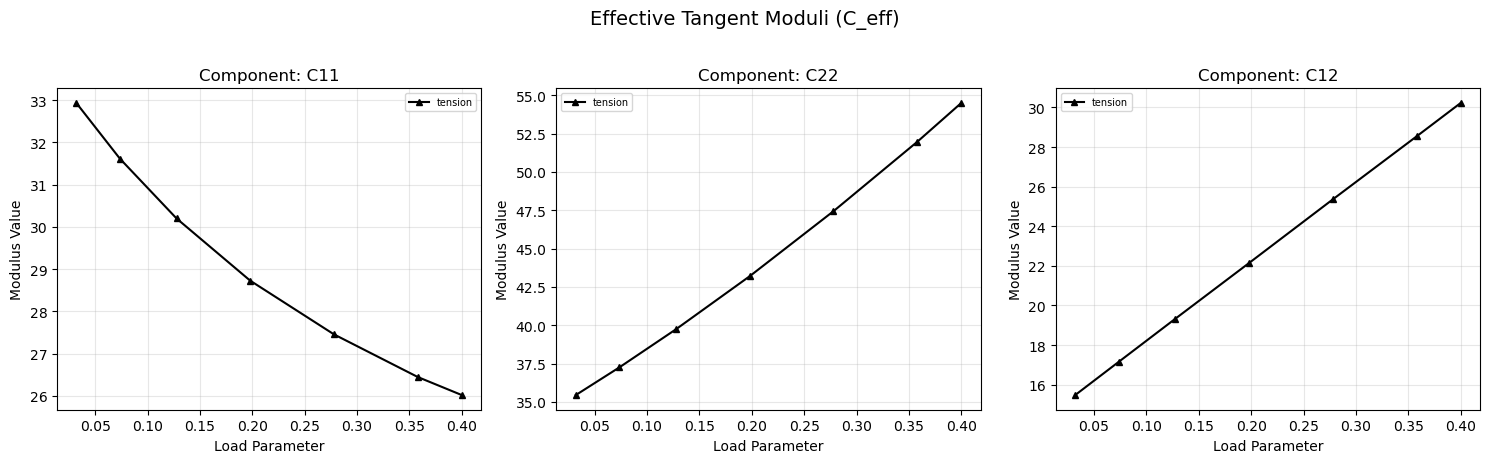

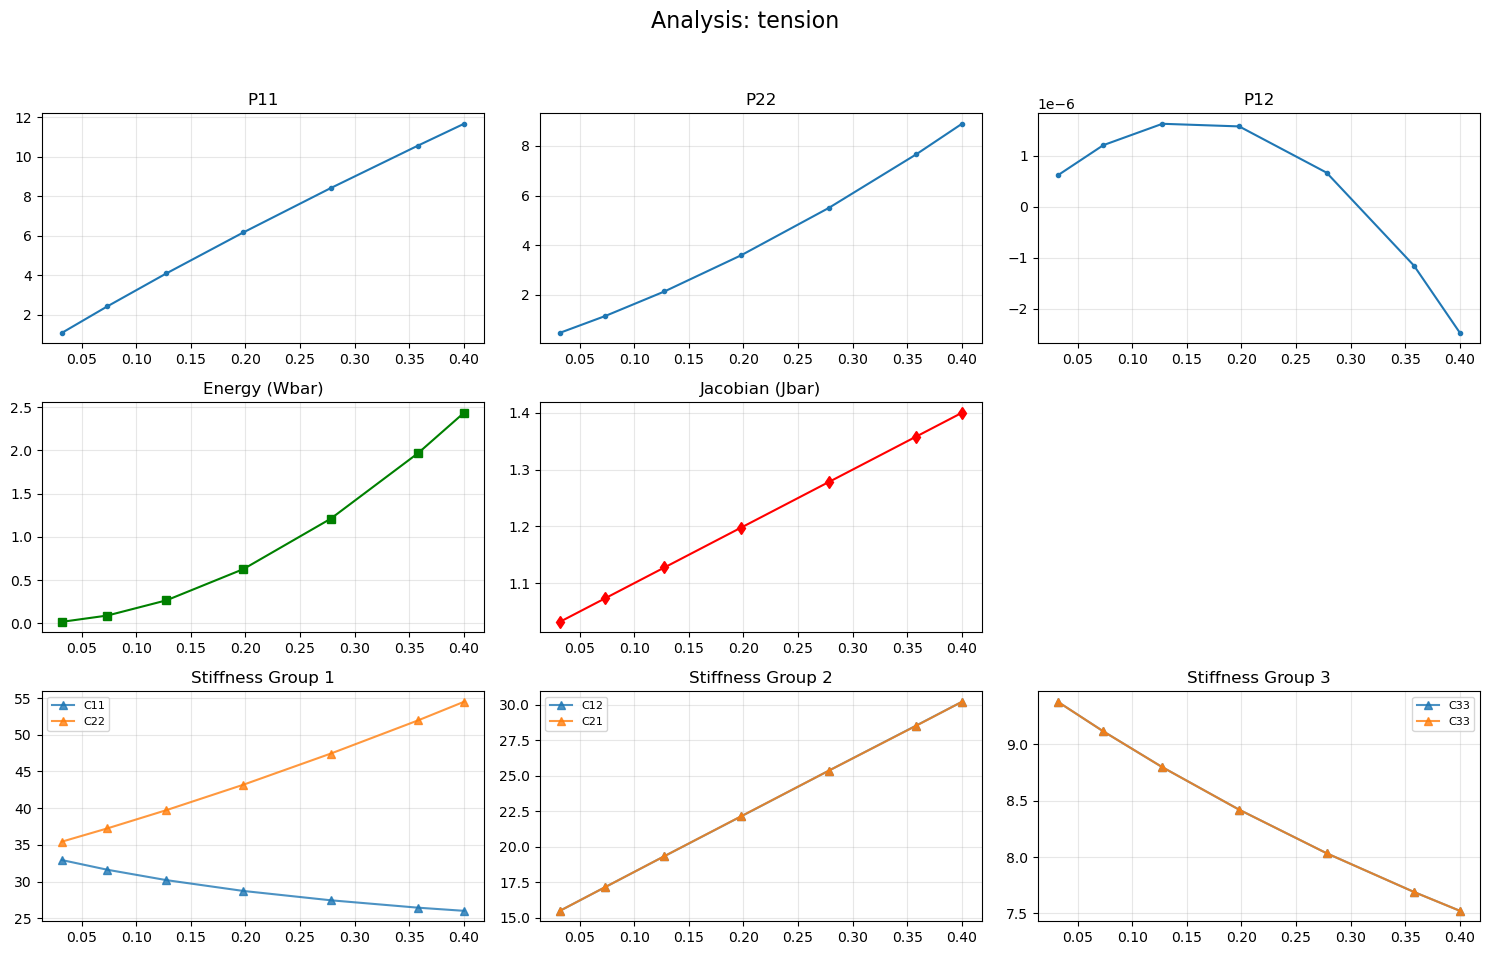

{'tension': {'load': array([0.032   , 0.0736  , 0.12768 , 0.197984, 0.277984, 0.357984,
       0.4     ]), 'P11': array([ 1.07239849,  2.41420535,  4.08434157,  6.1540718 ,  8.39971459,
       10.55470036, 11.65698095]), 'P22': array([0.47445293, 1.15312387, 2.13974333, 3.59820242, 5.49885159,
       7.65530779, 8.89009781]), 'Wbar': array([0.01725958, 0.08997092, 0.26603608, 0.62653709, 1.20937232,
       1.96808075, 2.43476815]), 'Jbar': array([1.032   , 1.0736  , 1.12768 , 1.197984, 1.277984, 1.357984,
       1.4     ]), 'P12': array([ 6.16841545e-07,  1.20706878e-06,  1.62625056e-06,  1.57485091e-06,
        6.68069205e-07, -1.15495558e-06, -2.47163919e-06]), 'P21': array([ 5.97714311e-07,  1.12431848e-06,  1.44211935e-06,  1.31364432e-06,
        5.22747499e-07, -8.50853276e-07, -1.76546793e-06]), 'C11': array([32.9331165 , 31.61485349, 30.20012514, 28.72787888, 27.45654413,
       26.44738926, 26.02016054]), 'C22': array([35.44491641, 37.25105583, 39.73803314, 43.19364782, 47.435

In [4]:
fem_settings = ProblemSettings(
    dim = dim,
    kinematics='finite_strain',
    two_dimensional_formulation='plane_strain',
    element_family='P',
    element_degree=1,
    petsc_options={
        "ksp_type": "gmres",
        "pc_type": "hypre",
        "snes_type": "newtonls",
        "snes_linesearch_type": "bt",
        "snes_rtol": 1e-8,
        "snes_atol": 1e-10,
        "snes_max_it": 10,
    }
)

def uni_tension_func(a):
    F = np.eye(2, dtype=PETSc.ScalarType)
    F[0, 0] = 1.0 + a
    return F

driver = NonlinearHomogenizationDriver(
    mesh_obj=domain,
    cell_tags=ct,
    facet_tags=ft,
    assignment=material_assignment,
    settings=fem_settings,
    physical_tags=physical_tags,
    domain_size=domain_size,
    matrix_phase_id=0,
    quad_degree=4,
    enable_hooks=False,
)

result = driver.run(
    tangent_every=1,
    output_prefix='rve',
    max_strain=0.4,
    custom_loads={
        'tension': uni_tension_func,
    },
    from_built_in_loads=[],
    adaptive_settings=AdaptiveSettings(
        initial_step_ratio=0.08,
        min_step= 1e-6,
        target_iters_min=4,
        target_iters_max=8,
        cutback_factor=0.8,
        growth_factor=1.3,
    ),
    xdmf_opt=False,
    csv_opt=False,
    plot_summary=True,
    plot_individual=True,
)

print(result.summary)